In [17]:
import dateutil as du
import datetime
#%matplotlib inline
import matplotlib.pyplot as plt
from math import ceil, floor
import numpy as np

import modules.URLhandler as URLhandler
import modules.timeHandler as timeHandler

In [18]:
# This handles the short-term DSCOVR data.
api_urlDSCOVR = "https://services.swpc.noaa.gov/json/dscovr/dscovr_mag_1s.json"

dataDSCOVR = URLhandler.URLcollectorJSON(api_urlDSCOVR, "DSCOVR short-term")

In [19]:
# This handles the estimated Kp index. Not the same as the actual Kp index.
api_urlKP = "https://services.swpc.noaa.gov/json/planetary_k_index_1m.json"

dataKP = URLhandler.URLcollectorJSON(api_urlKP, "Kp index")

In [20]:
# This handles the real-time solar wind magnetometer data.
api_urlRTSWmag = "https://services.swpc.noaa.gov/json/rtsw/rtsw_mag_1m.json"

dataRTSWmag = URLhandler.URLcollectorJSON(api_urlRTSWmag, "RTSW mag")

In [21]:
# This handles the real-time solar wind proton data.
api_urlRTSWwind = "https://services.swpc.noaa.gov/json/rtsw/rtsw_wind_1m.json"

dataRTSWwind = URLhandler.URLcollectorJSON(api_urlRTSWwind, "RTSW wind")

In [22]:
# This handles the GOES X-ray data. Primary is usually GOES-16.
api_urlGOESxray = "https://services.swpc.noaa.gov/json/goes/primary/xrays-7-day.json"

dataGOESxray = URLhandler.URLcollectorJSON(api_urlGOESxray, "GOES X-ray")

In [23]:
listOfDSCOVRbt = []
listOfDSCOVRbz = []
listOfDSCOVRbx = []
listOfDSCOVRby = []
listOfDSCOVRtimes = []

for i in dataDSCOVR:
    # For some of these, it is as easy as grabbing the data directly from the JSON file.
    listOfDSCOVRbt.append(i['bt'])
    listOfDSCOVRbz.append(i['bz_gsm'])
    listOfDSCOVRbx.append(i['bx_gsm'])
    listOfDSCOVRby.append(i['by_gsm'])

    listOfDSCOVRtimes.append(i['time_tag'])

In [24]:
listOfEstKP = []
listOfKPtimes = []

for i in dataKP:
    # This is the planetary Kp value. Updated every minute.
    # Seems to be revised upwards or downwards occasionally after the initial value.
    listOfEstKP.append(i['estimated_kp'])

    listOfKPtimes.append(i['time_tag'])

In [25]:
listOfEstKP[-1]

0.0

In [26]:
listOfRTSWmagBt = []
listOfRTSWmagBz = []
listOfRTSWmagBx = []
listOfRTSWmagBy = []
listOfRTSWmagTimes = []

# Set the Real-Time Solar Wind data source once for ease of changes.
RTSWdataSourceMain = "DSCOVR"
RTSWdataSourceBackup = "ACE"

for i in dataRTSWmag:
    # DSCOVR's data is more reliable and updates more frequently than ACE's data,
    # so I only collect DSCOVR's. This can be changed in the event of an outage.
    if(i['source'] == RTSWdataSourceMain):
        listOfRTSWmagBt.append(i['bt'])
        listOfRTSWmagBz.append(i['bz_gsm'])
        listOfRTSWmagBx.append(i['bx_gsm'])
        listOfRTSWmagBy.append(i['by_gsm'])

        listOfRTSWmagTimes.append(i['time_tag'])
    RTSWdataSource = RTSWdataSourceMain

# In the event that the primary satellite has not been reporting, switch to the backup option.
# Currently this is set to ACE, but the backup is configurable above.
if(listOfRTSWmagTimes == []):
    for i in dataRTSWmag:
        if(i['source'] == RTSWdataSourceBackup):
            listOfRTSWmagBt.append(i['bt'])
            listOfRTSWmagBz.append(i['bz_gsm'])
            listOfRTSWmagBx.append(i['bx_gsm'])
            listOfRTSWmagBy.append(i['by_gsm'])

            listOfRTSWmagTimes.append(i['time_tag'])
    RTSWdataSource = RTSWdataSourceBackup

In [ ]:
listOfRTSWwindDensity = []
listOfRTSWwindSpeed = []
listOfRTSWwindTimes = []
listOfRTSWtemperature = []

for i in dataRTSWwind:
    # DSCOVR's data is more reliable and updates more frequently than ACE's data,
    # so I only collect DSCOVR's. This can be changed in the event of an outage.
    if(i['source'] == RTSWdataSourceMain):
        # For some reason, it is possible for density to be zero.
        # I suspect that the SWPC is truncating the density data which goes to zero at low values.
        if(i['proton_density'] != 0):
            listOfRTSWwindDensity.append(i['proton_density'])
        else:
            listOfRTSWwindDensity.append(None)
        listOfRTSWwindSpeed.append(i['proton_speed'])
        listOfRTSWtemperature.append(i['proton_temperature'])

        listOfRTSWwindTimes.append(i['time_tag'])

# In the event that the primary satellite has not been reporting, switch to the backup option.
# Currently this is set to ACE, but the backup is configurable above.
if(listOfRTSWwindTimes == []):
    for i in dataRTSWwind:
        if(i['source'] == RTSWdataSourceBackup):
            # For some reason, it is possible for density to be zero.
            # I suspect that the SWPC is truncating the density data which goes to zero at low values.
            if(i['proton_density'] != 0):
                listOfRTSWwindDensity.append(i['proton_density'])
            else:
                listOfRTSWwindDensity.append(None)
            listOfRTSWwindSpeed.append(i['proton_speed'])
            listOfRTSWtemperature.append(i['proton_temperature'])

            listOfRTSWwindTimes.append(i['time_tag'])

In [35]:
listOfGOESxrayLong = []
listOfGOESxrayShort = []
listOfGOEStimes = []

for i in dataGOESxray:
    # Because the x-ray flux is separated into two different ranges,
    # we need to break it into short- and long-wave x-rays.
    if(i['energy'] == "0.05-0.4nm"):
        listOfGOESxrayShort.append(i['flux'])

    if(i['energy'] == "0.1-0.8nm"):
        listOfGOESxrayLong.append(i['flux'])

        listOfGOEStimes.append(i['time_tag'])

In [36]:
# Parse the timestamps into the correct format for plotting.
newTimestampDSCOVR = timeHandler.timeParser(listOfDSCOVRtimes)
newTimestampKP = timeHandler.timeParser(listOfKPtimes)
newTimestampRTSWmag = timeHandler.timeParser(listOfRTSWmagTimes)
newTimestampRTSWwind = timeHandler.timeParser(listOfRTSWwindTimes)
newTimestampGOESxray = timeHandler.timeParser(listOfGOEStimes)

# This is used to calculate the offset that has to be applied to the rectangles to allow them to be charted.
# Outputs the time in days since January 1, 1970 which is the date from which datetime calculates for the numeric equivalent.
# Technically, from 18Z December 31, 1969 due to time zones. Will need to be adjusted for DST.
dateInitial = datetime.datetime(1969,12,31,19,0)
dateCurrent = datetime.datetime.now()
dateOffset = (dateCurrent - dateInitial).total_seconds()/86400

In [37]:
# Calculates the approximate conditions that are currently hitting Earth.
# Distance from Earth to DSCOVR, in kilometers.
distanceDSCOVR = 1472000

# Outputs time in days and minutes using latest solar wind speed data.
timeToArrival = (distanceDSCOVR / listOfRTSWwindSpeed[0]) / (24*60*60)
timeToArrivalMinutes = round(timeToArrival * (24 * 60))
print(timeToArrival)
print(timeToArrivalMinutes)

0.03698076196448239
53


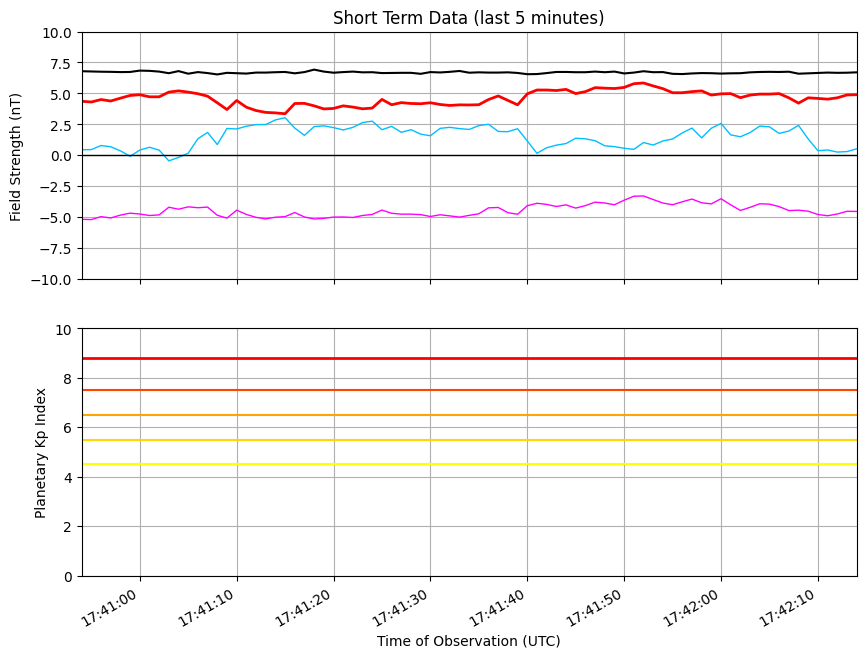

In [38]:
plt.rcParams["figure.dpi"] = 100
fig, (ax1, ax2) = plt.subplots(2, figsize=(10, 8))

# Set the size of the viewing window for the magnetometer data.
# Because sudden spikes can appear, this adjusts automatically.
magViewingLimitS = max(ceil(max((listOfDSCOVRbt), key=abs)/10)*10, 10)
magLimitS = [-magViewingLimitS, magViewingLimitS]

# The order of these plots matter for layering.
ax1.plot(newTimestampDSCOVR, listOfDSCOVRbx, color='magenta', linewidth=1)
ax1.plot(newTimestampDSCOVR, listOfDSCOVRby, color='deepskyblue', linewidth=1)
ax1.plot(newTimestampDSCOVR, listOfDSCOVRbt, color='black', linewidth=1.5)
ax1.plot(newTimestampDSCOVR, listOfDSCOVRbz, color='red', linewidth=2)

ax2.plot(newTimestampKP, listOfEstKP, color='green')

# Bolded centerline for the magnetometer 0 nT mark.
ax1.hlines(y=0, xmin=0, xmax=dateOffset, linewidth=1, color='k')

# Mark out the different geomagnetic categories (G1-G5).
ax2.hlines(y=4.5, xmin=0, xmax=dateOffset, linewidth=1.5, color='yellow')
ax2.hlines(y=5.5, xmin=0, xmax=dateOffset, linewidth=1.5, color='gold')
ax2.hlines(y=6.5, xmin=0, xmax=dateOffset, linewidth=1.5, color='orange')
ax2.hlines(y=7.5, xmin=0, xmax=dateOffset, linewidth=1.5, color='orangered')
ax2.hlines(y=8.80, xmin=0, xmax=dateOffset, linewidth=2, color='red')

plt.setp(ax1, xlim=[newTimestampDSCOVR[-1], newTimestampDSCOVR[0]], ylim=magLimitS)
plt.setp(ax2, xlim=[newTimestampDSCOVR[-1], newTimestampDSCOVR[0]], ylim=[0, 10])

ax1.grid(True)
ax2.grid(True)

ax1.set_title("Short Term Data (last 5 minutes)")
ax1.set_ylabel("Field Strength (nT)")
ax2.set_ylabel("Planetary Kp Index")
ax2.set_xlabel("Time of Observation (UTC)")

fig.autofmt_xdate()

plt.show()

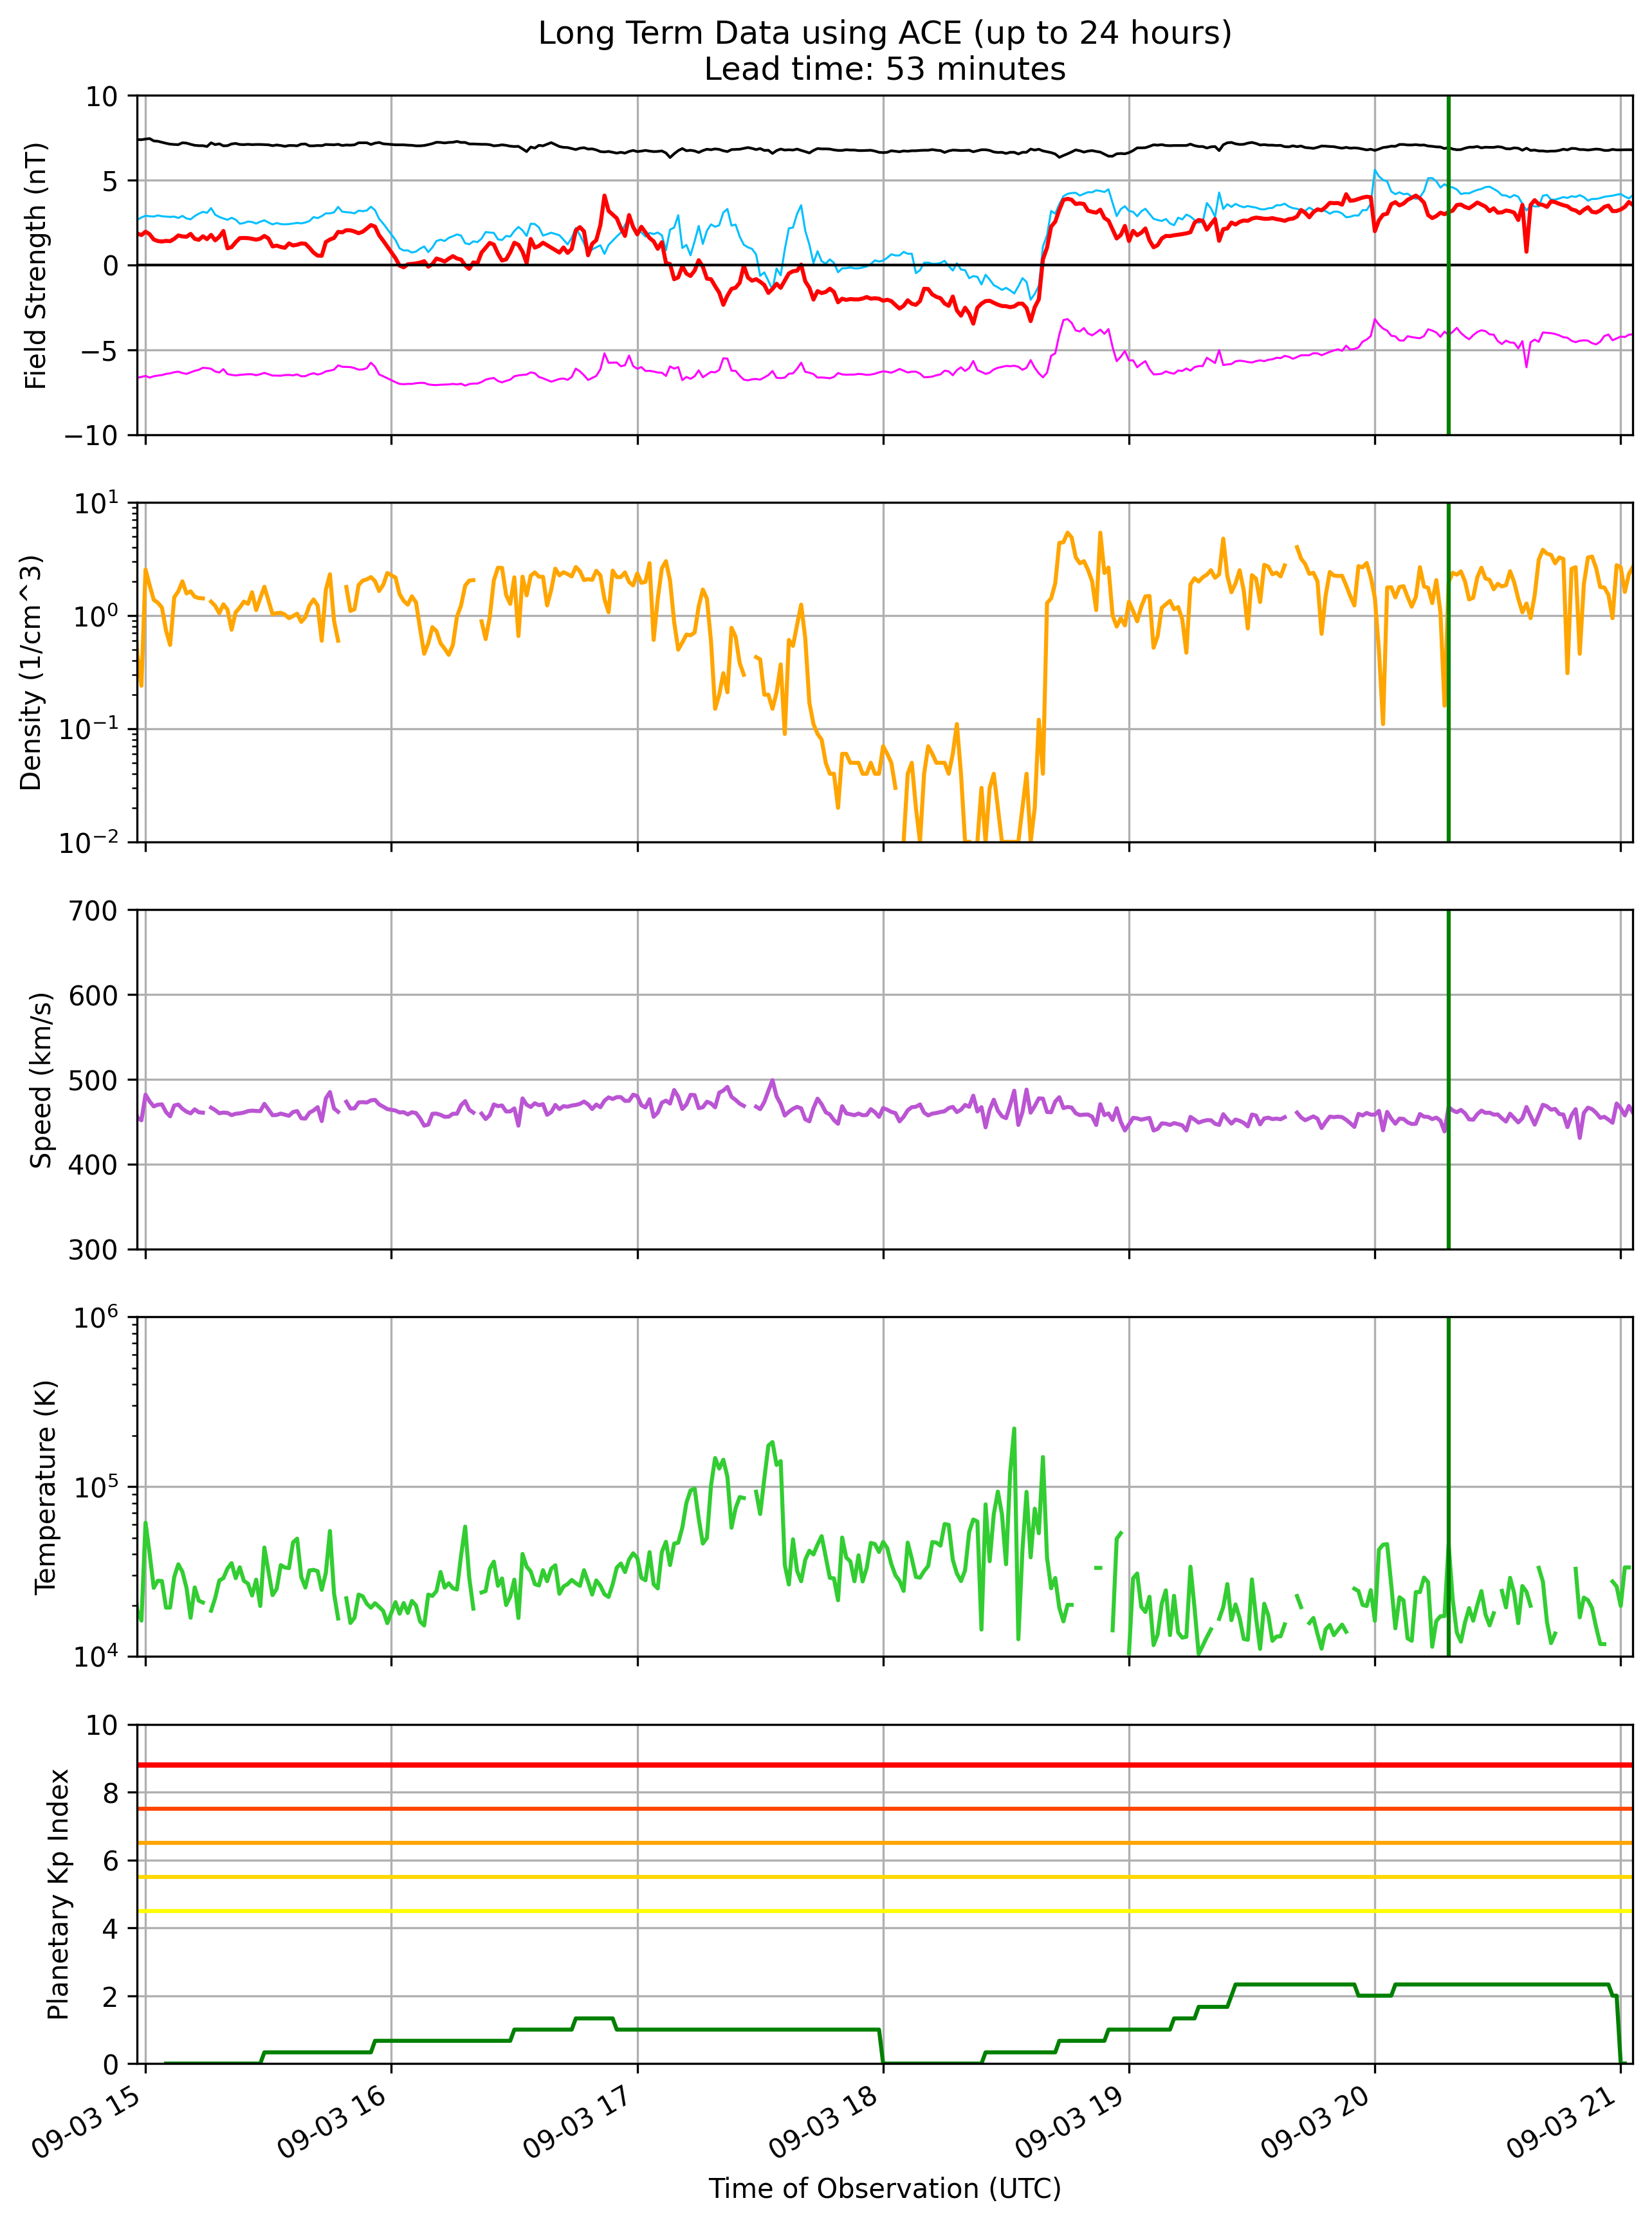

In [39]:
plt.rcParams["figure.dpi"] = 300
fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(5, figsize=(10,15))

# The order of these plots matter for layering.
ax1.plot(newTimestampRTSWmag, listOfRTSWmagBx, color='magenta', linewidth=0.75)
ax1.plot(newTimestampRTSWmag, listOfRTSWmagBy, color='deepskyblue', linewidth=0.75)
ax1.plot(newTimestampRTSWmag, listOfRTSWmagBt, color='black', linewidth=1)
ax1.plot(newTimestampRTSWmag, listOfRTSWmagBz, color='red', linewidth=1.5)

ax2.plot(newTimestampRTSWwind, listOfRTSWwindDensity, color='orange')

ax3.plot(newTimestampRTSWwind, listOfRTSWwindSpeed, color='mediumorchid')

ax4.plot(newTimestampRTSWwind, listOfRTSWtemperature, color='limegreen')

ax5.plot(newTimestampKP, listOfEstKP, color="green")

# Sets the y-scale to logarithmic.
ax2.set_yscale('log')
ax4.set_yscale('log')

# Number of minutes to be plotted.
minutesPlotted = 360
RTSWtimeLimit = [newTimestampRTSWmag[minutesPlotted], newTimestampRTSWmag[0]]

# Set the size of the viewing window for the magnetometer data.
# Because sudden spikes can appear, this adjusts automatically.
magViewingLimitL = max(ceil(max((listOfRTSWmagBt[:minutesPlotted]), key=abs)/10)*10, 10)
magLimitL = [-magViewingLimitL, magViewingLimitL]

# Set the limits on how much data is plotted vertically.
# Starts with density.
densityHigh = np.power(float(10), ceil(np.log10(max([i for i in listOfRTSWwindDensity[:minutesPlotted] if i is not None]))))
densityLow = np.power(float(10), floor(np.log10(min([i for i in listOfRTSWwindDensity[:minutesPlotted] if i is not None]))))
densityLimit = [densityLow, densityHigh]

# Then goes to solar wind speed.
speedMax = max(ceil(max([i for i in listOfRTSWwindSpeed[:minutesPlotted] if i is not None])/100)*100, 700)
speedMin = min(ceil(min([i for i in listOfRTSWwindSpeed[:minutesPlotted] if i is not None])/100)*100, 300)
speedLimit = [speedMin, speedMax]

# Wraps up with the temperature data.
tempHigh = np.power(float(10), ceil(np.log10(max([i for i in listOfRTSWtemperature[:minutesPlotted] if i is not None]))))
tempLow = np.power(float(10), floor(np.log10(min([i for i in listOfRTSWtemperature[:minutesPlotted] if i is not None]))))
tempLimit = [tempLow, tempHigh]

# Set the actual bounds of each plot.
plt.setp(ax1, xlim=RTSWtimeLimit, ylim=magLimitL) # Magnetic (nT)
plt.setp(ax2, xlim=RTSWtimeLimit, ylim=densityLimit) # Density (cm^-3) 
plt.setp(ax3, xlim=RTSWtimeLimit, ylim=speedLimit) # Speed (km/s)
plt.setp(ax4, xlim=RTSWtimeLimit, ylim=tempLimit) # Temperature (K)
plt.setp(ax5, xlim=RTSWtimeLimit, ylim=[0, 10]) #Kp index

# Bolded centerline for the magnetometer 0 nT mark.
ax1.hlines(y=0, xmin=0, xmax=dateOffset, linewidth=1, color='k')

# Mark out the different geomagnetic categories (G1-G5).
ax5.hlines(y=4.5, xmin=0, xmax=dateOffset, linewidth=1.5, color='yellow')
ax5.hlines(y=5.5, xmin=0, xmax=dateOffset, linewidth=1.5, color='gold')
ax5.hlines(y=6.5, xmin=0, xmax=dateOffset, linewidth=1.5, color='orange')
ax5.hlines(y=7.5, xmin=0, xmax=dateOffset, linewidth=1.5, color='orangered')
ax5.hlines(y=8.80, xmin=0, xmax=dateOffset, linewidth=2, color='red')

# Draw lines at the estimated solar wind parameters arriving at Earth now.
ax1.vlines(x=dateOffset-timeToArrival, ymin=magLimitL[0], ymax=magLimitL[1], linewidth=1.5, color='g')
ax2.vlines(x=dateOffset-timeToArrival, ymin=densityLimit[0], ymax=densityLimit[1], linewidth=1.5, color='g')
ax3.vlines(x=dateOffset-timeToArrival, ymin=speedLimit[0], ymax=speedLimit[1], linewidth=1.5, color='g')
ax4.vlines(x=dateOffset-timeToArrival, ymin=tempLimit[0], ymax=tempLimit[1], linewidth=1.5, color='g')

ax1.grid(True)
ax2.grid(True)
ax3.grid(True)
ax4.grid(True)
ax5.grid(True)

ax1.set_title("Long Term Data using " + RTSWdataSource + " (up to 24 hours)\n" + \
              "Lead time: " + str(timeToArrivalMinutes) + " minutes")
ax1.set_ylabel("Field Strength (nT)")
ax2.set_ylabel("Density (1/cm^3)")
ax3.set_ylabel("Speed (km/s)")
ax4.set_ylabel("Temperature (K)")
ax5.set_ylabel("Planetary Kp Index")
ax5.set_xlabel("Time of Observation (UTC)")

fig.autofmt_xdate()

plt.show()

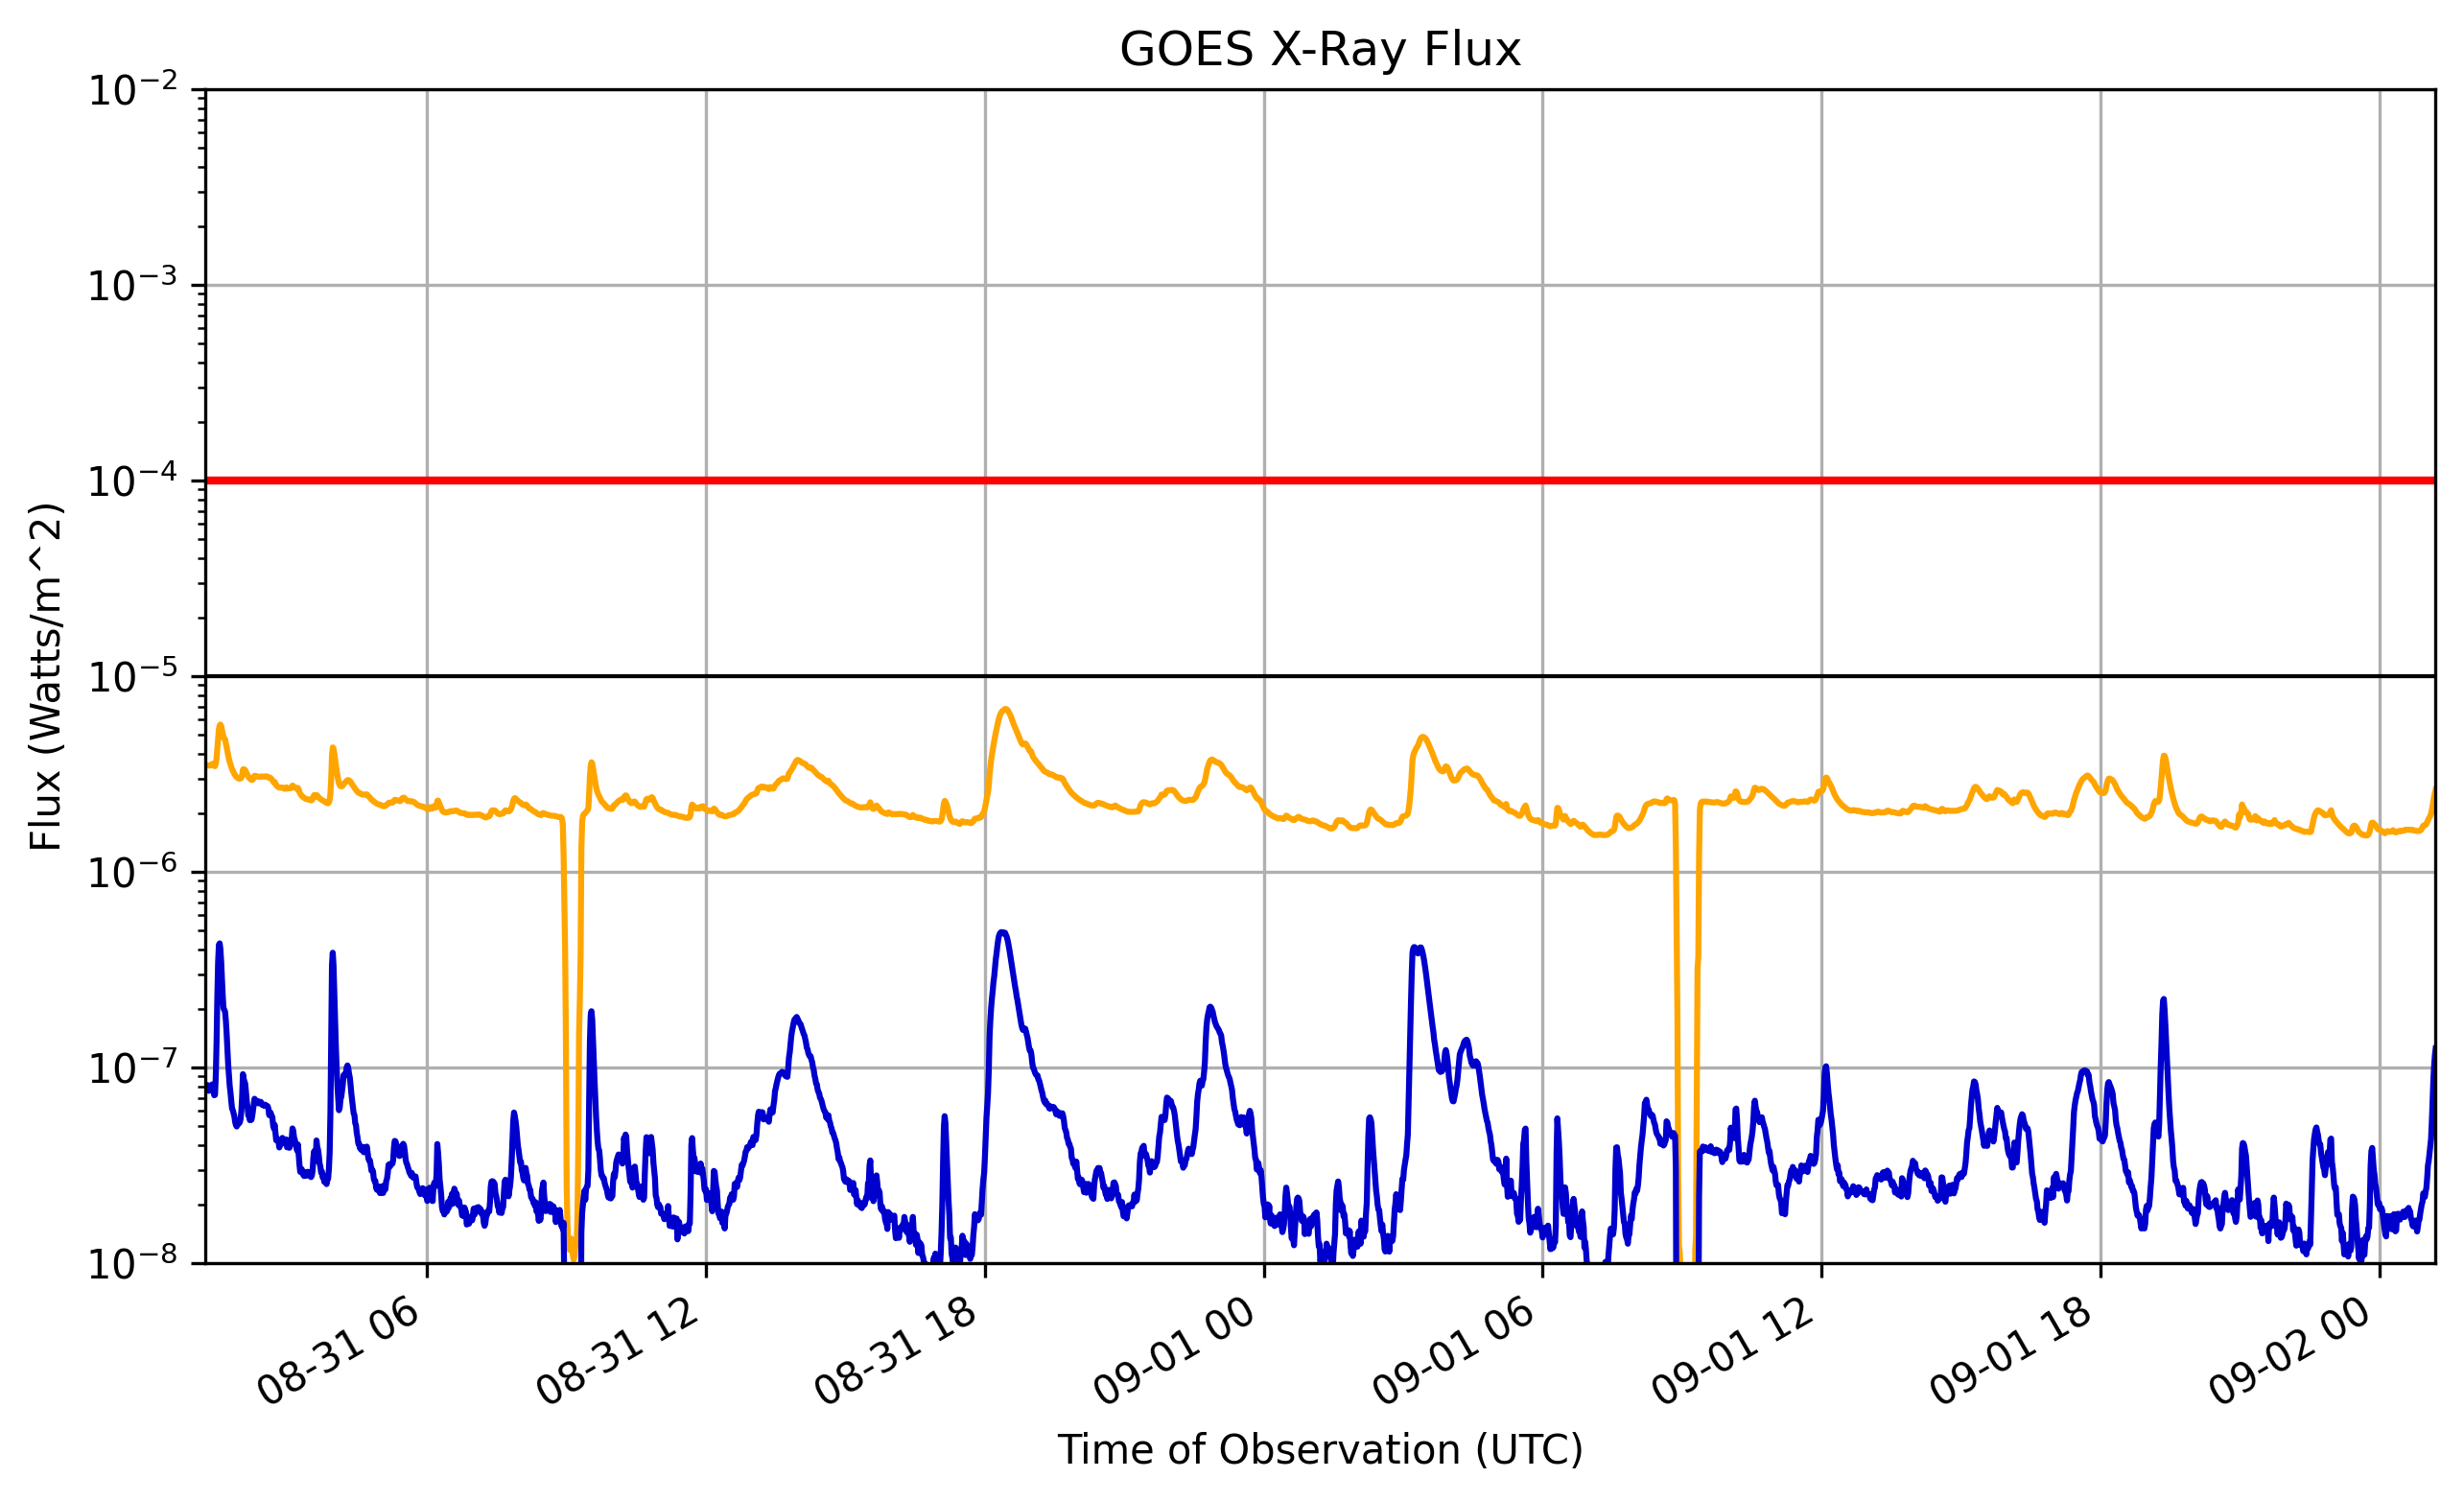

In [ ]:
plt.rcParams["figure.dpi"] = 300
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(newTimestampGOESxray, listOfGOESxrayLong, color='orange')
ax.plot(newTimestampGOESxray, listOfGOESxrayShort, color='mediumblue')

# Plots the data between two limits for the given time frame. Currently set from A1 to X100.
# An X100 would be interesting, to say the least.
hoursPlottedXray = 48
minutesPlottedXray = hoursPlottedXray * 60
plt.setp(ax, xlim=[newTimestampGOESxray[-minutesPlottedXray], newTimestampGOESxray[-1]], ylim=[0.00000001, 0.01])

# Lines for M- (black) and X- (red) class X-ray flares.
ax.hlines(y=0.00001, xmin=0, xmax=dateOffset+1, linewidth=1, color='k')
ax.hlines(y=0.0001, xmin=0, xmax=dateOffset+1, linewidth=2, color='r')

# Sets the y-scale to logarithmic.
ax.set_yscale('log')

ax.grid(True)

ax.set_title("GOES X-Ray Flux")
ax.set_xlabel("Time of Observation (UTC)")
ax.set_ylabel("Flux (Watts/m^2)")
fig.autofmt_xdate()

plt.show()